## 🏠 Ames House Price Prediction

Predicting residential house sale prices using machine learning regression techniques.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/AmesHousing.csv')

### Initial Data Exploration

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
#Statistical Summary (Numerical Features)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [7]:
#Statistical Summary (Categorical Features)
df.describe(include="object").T

,count,unique,top,freq
MS Zoning,2930,7,RL,2273
Street,2930,2,Pave,2918
Alley,198,2,Grvl,120
Lot Shape,2930,4,Reg,1859
Land Contour,2930,4,Lvl,2633
Utilities,2930,3,AllPub,2927
Lot Config,2930,5,Inside,2140
Land Slope,2930,3,Gtl,2789
Neighborhood,2930,28,NAmes,443
Condition 1,2930,9,Norm,2522


In [8]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [9]:
df.nunique().sort_values()

Central Air          2
Street               2
Alley                2
Bsmt Half Bath       3
Paved Drive          3
                  ... 
Bsmt Unf SF       1137
Gr Liv Area       1292
Lot Area          1960
PID               2930
Order             2930
Length: 82, dtype: int64

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical Features   : {len(num_cols)}")
print(f"Categorical Features : {len(cat_cols)}")

Numerical Features   : 39
Categorical Features : 43


In [11]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

In [12]:
summary.head()

,Data Type,Missing Values,Unique Values
Order,int64,0,2930
PID,int64,0,2930
MS SubClass,int64,0,16
MS Zoning,object,0,7
Lot Frontage,float64,490,128


### Data Cleaning

In [13]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Count"] > 0]
missing_values.sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Cond,159,5.426621
Garage Qual,159,5.426621
Garage Finish,159,5.426621


In [14]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [15]:
df.drop(columns=["Order", "PID"], inplace=True)

### Exploratory Data Analysis (EDA)

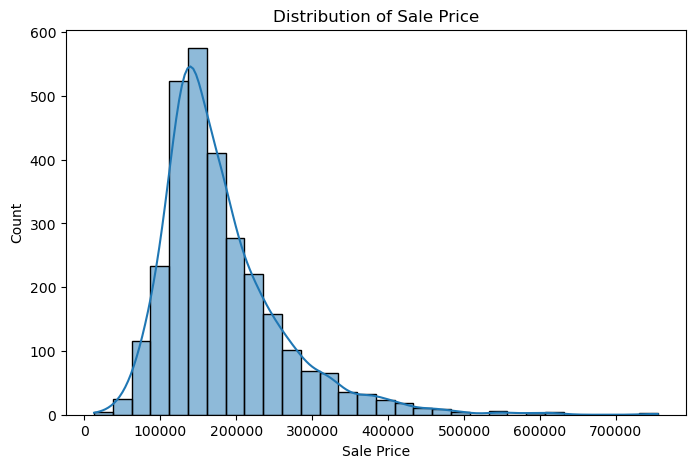

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.show()

In [17]:
print("Skewness :", df["SalePrice"].skew())

Skewness : 1.7435000757376466


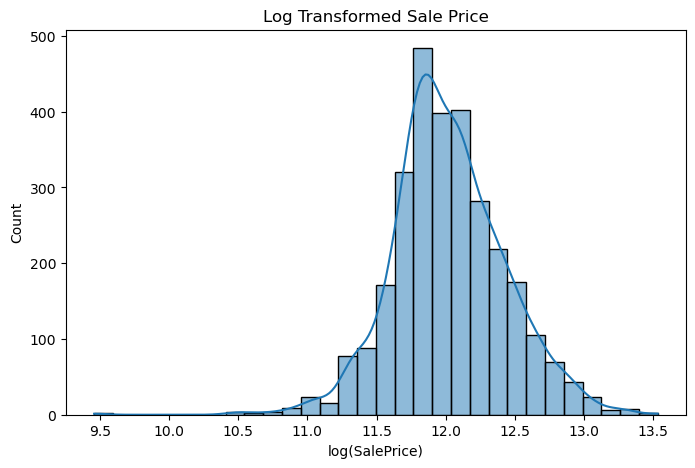

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["SalePrice"]), bins=30, kde=True)

plt.title("Log Transformed Sale Price")
plt.xlabel("log(SalePrice)")

plt.show()

In [19]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

corr

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0

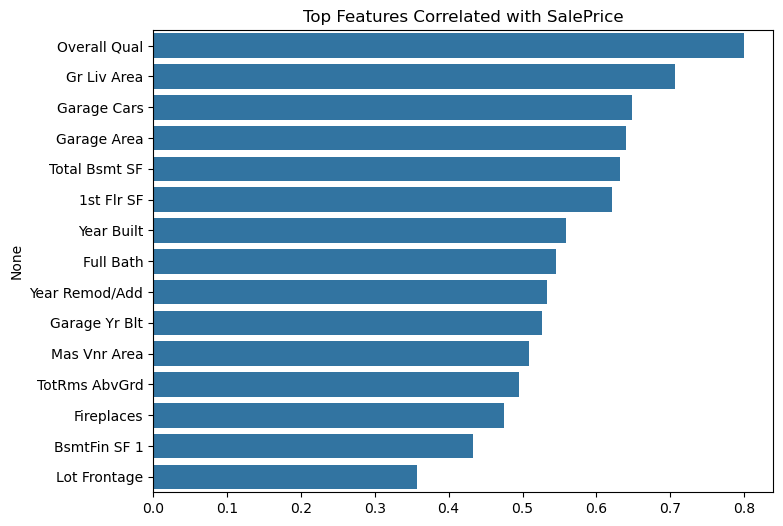

In [20]:
# Top 15 Features Correlated with SalePrice
top_corr = corr[1:16]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values,y=top_corr.index)

plt.title("Top Features Correlated with SalePrice")
plt.show()

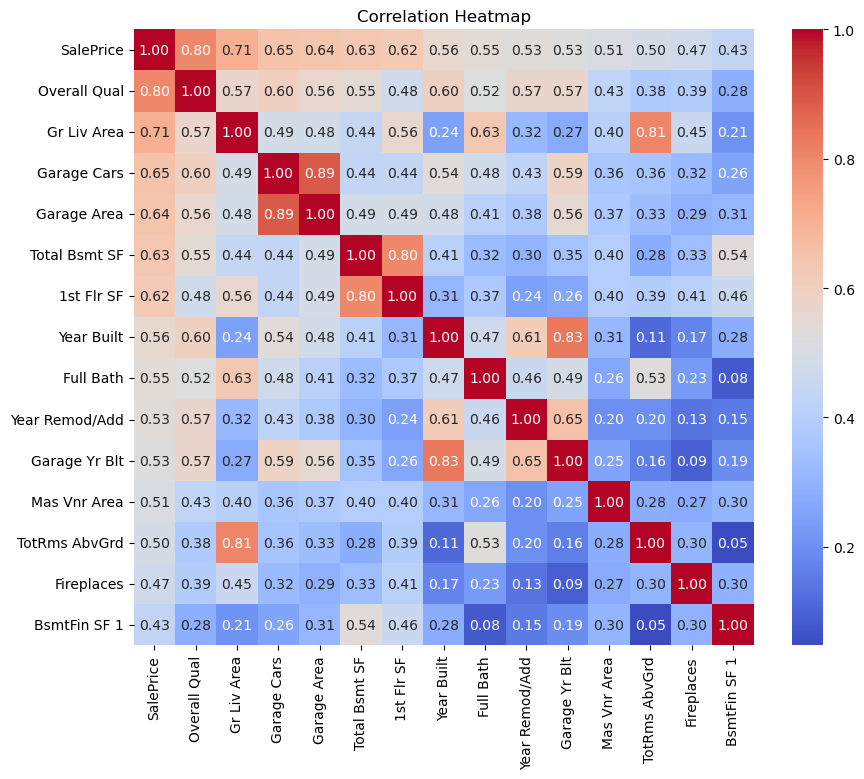

In [21]:
top_features = corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

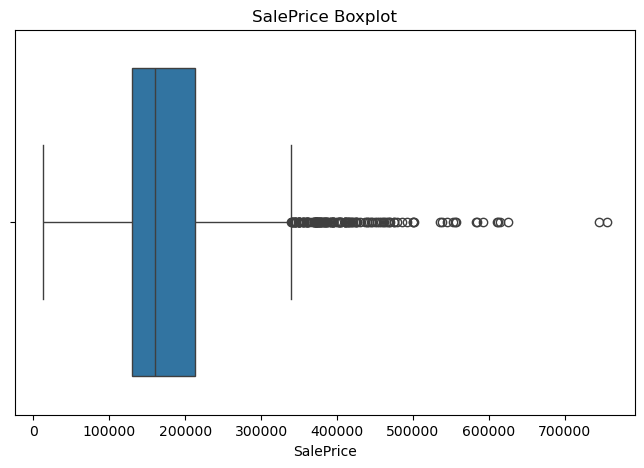

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["SalePrice"])

plt.title("SalePrice Boxplot")
plt.show()

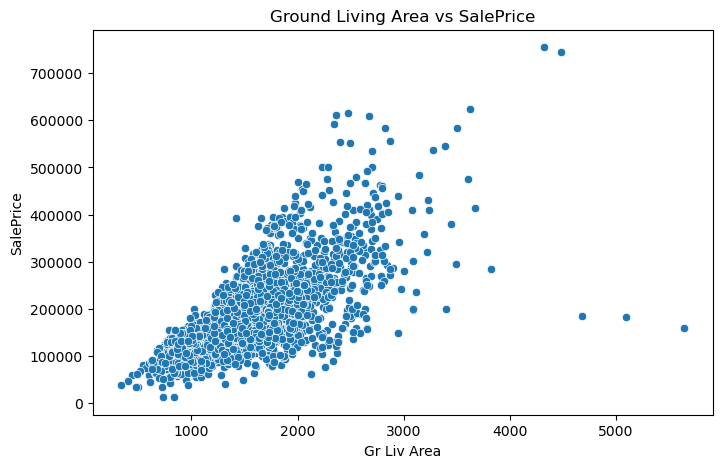

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Gr Liv Area",y="SalePrice",data=df)

plt.title("Ground Living Area vs SalePrice")
plt.show()

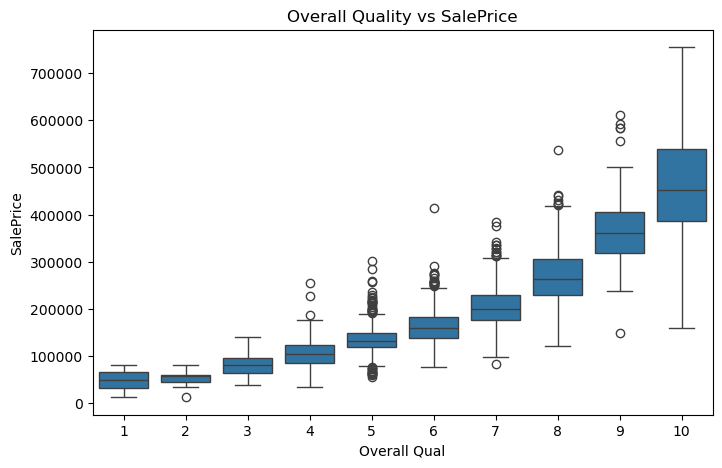

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Overall Qual",y="SalePrice",data=df)

plt.title("Overall Quality vs SalePrice")
plt.show()

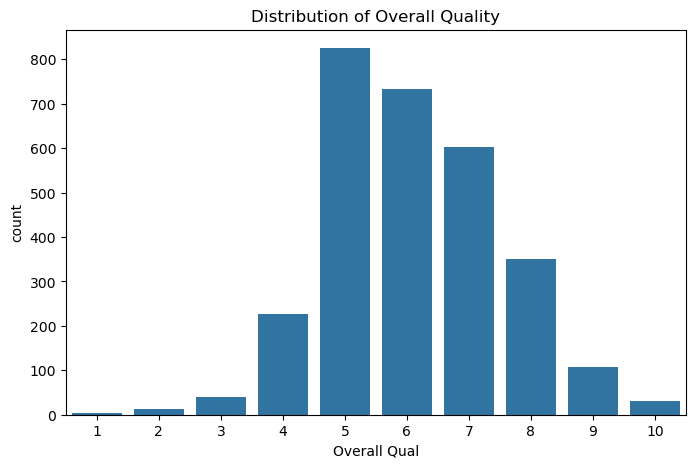

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Overall Qual')

plt.title('Distribution of Overall Quality')
plt.show()

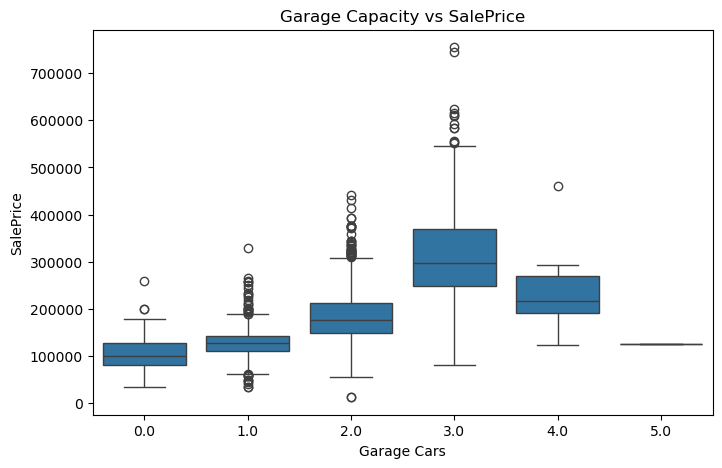

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Garage Cars",y="SalePrice",data=df)

plt.title("Garage Capacity vs SalePrice")
plt.show()

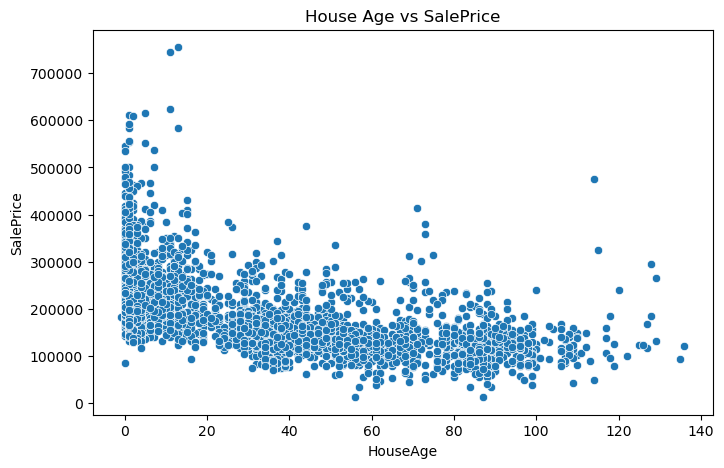

In [27]:
df['HouseAge'] = (df['Yr Sold'] - df['Year Built'])

plt.figure(figsize=(8,5))

sns.scatterplot(x='HouseAge',y='SalePrice',data=df)

plt.title('House Age vs SalePrice')
plt.show()

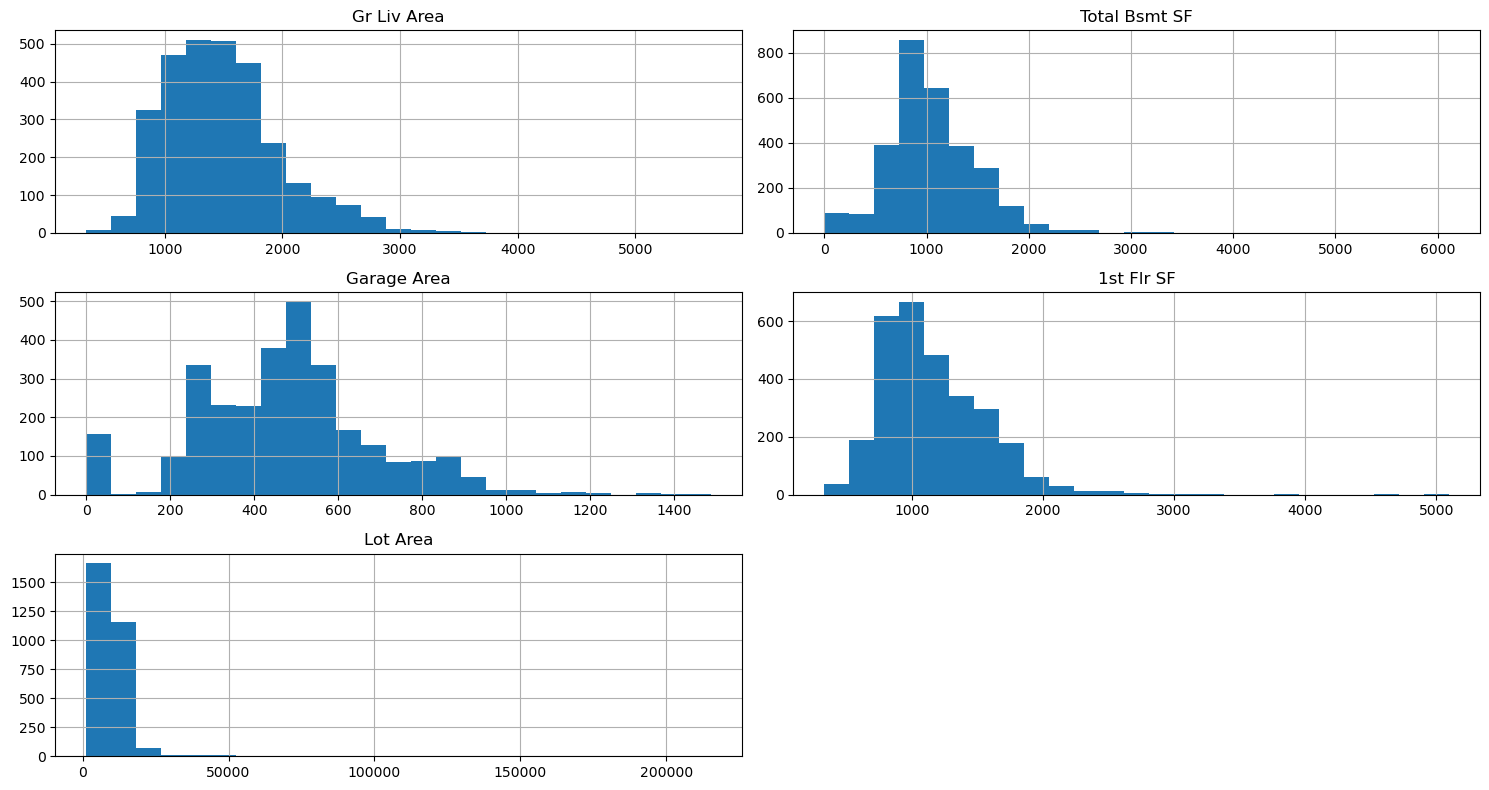

In [28]:
important_num = [
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area",
    "1st Flr SF",
    "Lot Area"
]

df[important_num].hist(
    figsize=(15,8),
    bins=25
)

plt.tight_layout()

plt.show()

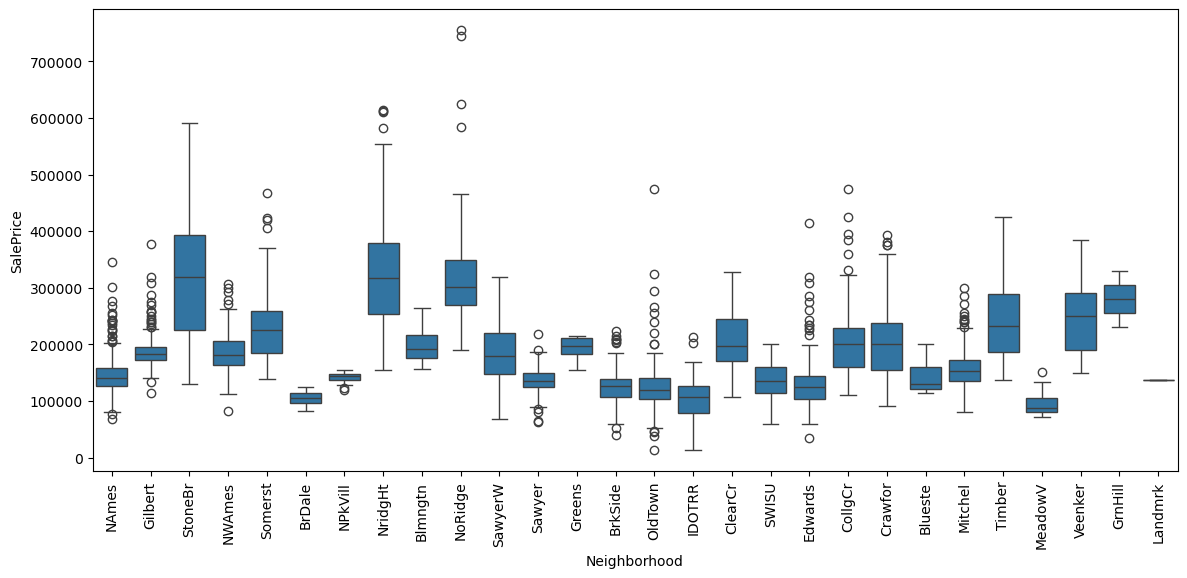

In [29]:
plt.figure(figsize=(14,6))
sns.boxplot(x="Neighborhood",y="SalePrice",data=df)

plt.xticks(rotation=90)
plt.show()

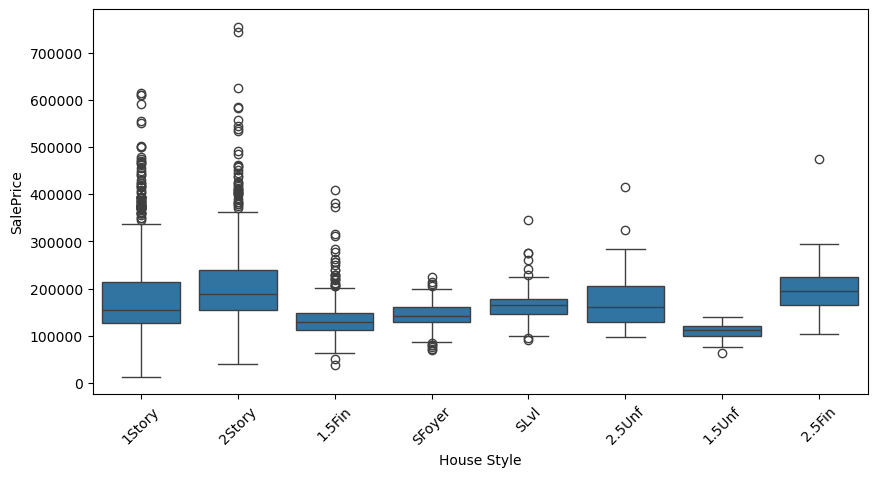

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x="House Style",y="SalePrice",data=df)

plt.xticks(rotation=45)
plt.show()

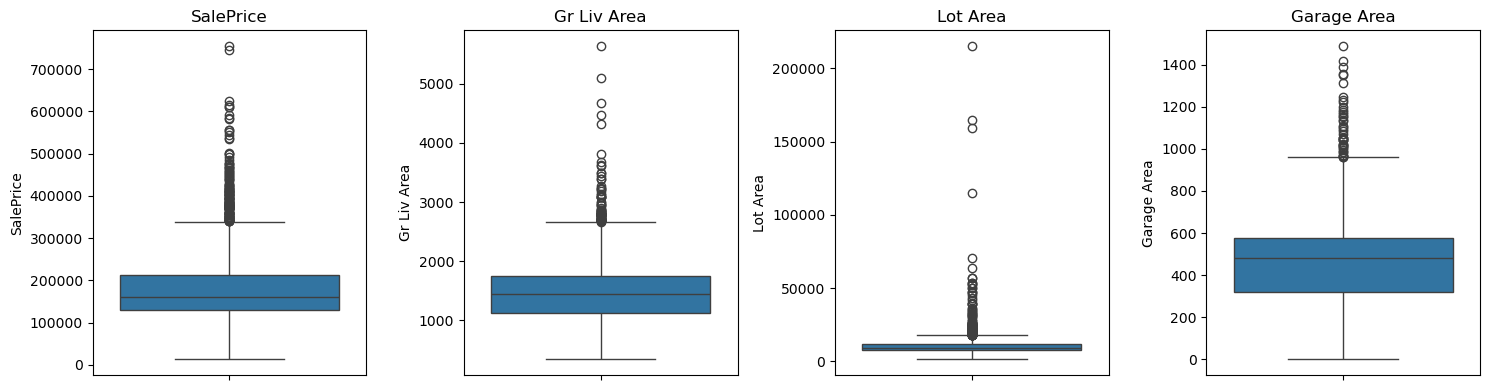

In [31]:
features = [
    'SalePrice',
    'Gr Liv Area',
    'Lot Area',
    'Garage Area'
]

plt.figure(figsize=(15,4))

for i, col in enumerate(features):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [32]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Feature Engineering

In [33]:
df_fe = df.copy()

In [34]:
df_fe['HouseAge'] = df_fe['Yr Sold'] - df_fe['Year Built']

In [35]:
df_fe['RemodelAge'] = df_fe['Yr Sold'] - df_fe['Year Remod/Add']

In [36]:
df_fe['TotalBathrooms'] = (
    df_fe['Full Bath']
    + 0.5 * df_fe['Half Bath']
    + df_fe['Bsmt Full Bath']
    + 0.5 * df_fe['Bsmt Half Bath']
)

In [37]:
df_fe['TotalPorchSF'] = (
    df_fe['Open Porch SF']
    + df_fe['Enclosed Porch']
    + df_fe['3Ssn Porch']
    + df_fe['Screen Porch']
)

In [38]:
df_fe['TotalLivingArea'] = (df_fe['Gr Liv Area']+ df_fe['Total Bsmt SF'])

In [39]:
df_fe['TotalHouseArea'] = (
    df_fe['Total Bsmt SF']
    + df_fe['1st Flr SF']
    + df_fe['2nd Flr SF']
)

In [40]:
df_fe['TotalOutdoorArea'] = (
    df_fe['Wood Deck SF']
    + df_fe['Open Porch SF']
    + df_fe['Enclosed Porch']
    + df_fe['3Ssn Porch']
    + df_fe['Screen Porch']
)

In [41]:
df_fe['TotalRooms'] = (df_fe['TotRms AbvGrd']+ df_fe['Bedroom AbvGr'])

In [42]:
df_fe['HasGarage'] = (df_fe['Garage Area'] > 0).astype(int)

In [43]:
df_fe['HasBasement'] = (df_fe['Total Bsmt SF'] > 0).astype(int)

In [44]:
df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)

In [45]:
df_fe['HasPool'] = (df_fe['Pool Area'] > 0).astype(int)

In [46]:
df_fe['HasSecondFloor'] = (df_fe['2nd Flr SF'] > 0).astype(int)

In [47]:
df_fe['GarageAge'] = (df_fe['Yr Sold']- df_fe['Garage Yr Blt'])

In [48]:
new_features = [
    'HouseAge',
    'RemodelAge',
    'TotalBathrooms',
    'TotalPorchSF',
    'TotalLivingArea',
    'TotalHouseArea',
    'TotalOutdoorArea',
    'TotalRooms',
    'HasGarage',
    'HasBasement',
    'HasFireplace',
    'HasPool',
    'HasSecondFloor',
    'GarageAge'
]

df_fe[new_features].head()

,HouseAge,RemodelAge,TotalBathrooms,TotalPorchSF,TotalLivingArea,TotalHouseArea,TotalOutdoorArea,TotalRooms,HasGarage,HasBasement,HasFireplace,HasPool,HasSecondFloor,GarageAge
0,50,50,2.0,62,2736.0,2736.0,272,10,1,1,1,0,0,50.0
1,49,49,1.0,120,1778.0,1778.0,260,7,1,1,0,0,0,49.0
2,52,52,1.5,36,2658.0,2658.0,429,9,1,1,0,0,0,52.0
3,42,42,3.5,0,4220.0,4220.0,0,11,1,1,1,0,0,42.0
4,13,12,2.5,34,2557.0,2557.0,246,9,1,1,1,0,1,13.0


### Target Variable Transformation

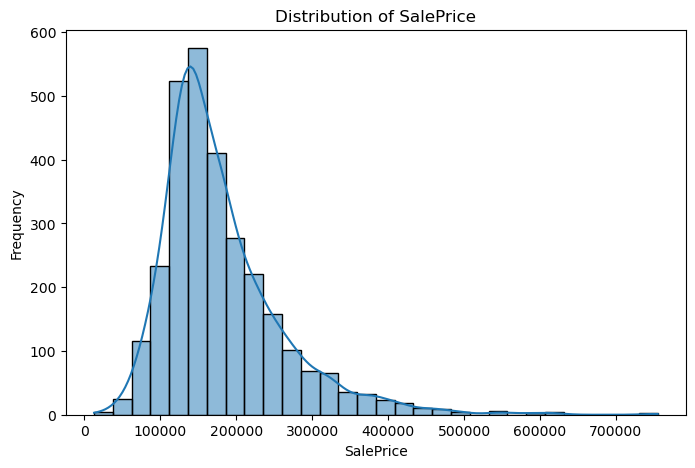

Skewness: 1.7435


In [49]:
plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()

print(f"Skewness: {df_fe['SalePrice'].skew():.4f}")

In [50]:
df_fe['SalePrice'] = np.log1p(df_fe['SalePrice'])

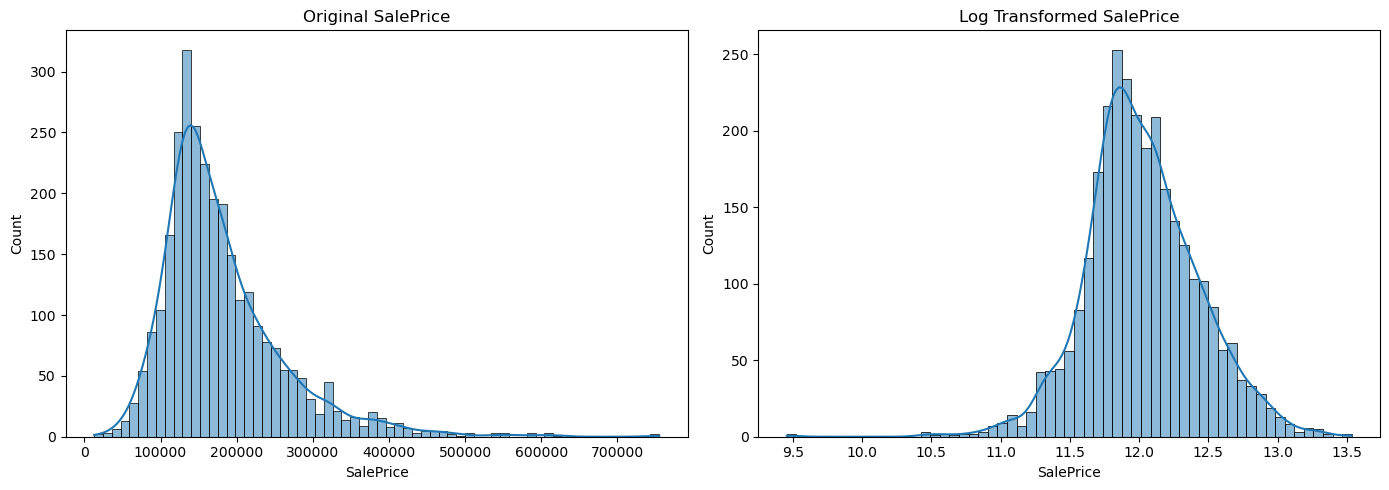

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_fe['SalePrice'].apply(np.expm1), kde=True, ax=axes[0])
axes[0].set_title("Original SalePrice")

sns.histplot(df_fe['SalePrice'], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed SalePrice")

plt.tight_layout()
plt.show()

In [52]:
print(f"Skewness after transformation: {df_fe['SalePrice'].skew():.4f}")

Skewness after transformation: -0.0148


### Train-Test Split

In [53]:
X = df_fe.drop("SalePrice", axis=1)
y = df_fe["SalePrice"]

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (2344, 93)
Testing Set  : (586, 93)


### Data Preprocessing 

In [55]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]).columns.tolist()

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 50
Categorical Features : 43


In [56]:
none_columns = [
    "Pool QC", "Alley", "Fence", "Fireplace Qu",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Misc Feature"
]

X_train[none_columns] = X_train[none_columns].fillna("None")
X_test[none_columns] = X_test[none_columns].fillna("None")

In [57]:
for df in [X_train, X_test]:
    if "GarageYrBlt" in df.columns:
        df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [58]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (OneHotEncoder,StandardScaler)

In [59]:
numeric_pipeline = Pipeline(
    steps=[( "imputer",
            SimpleImputer(strategy="median")),
        ( "scaler", StandardScaler() )]
)

In [60]:
categorical_pipeline = Pipeline(
    steps=[( "imputer",
            SimpleImputer(strategy="most_frequent")),
        ( "encoder", OneHotEncoder( handle_unknown="ignore" ) )]
)

In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        ( "num",
            numeric_pipeline,
            numerical_features ),
        ( "cat",
            categorical_pipeline,
            categorical_features )
        ]
    )

In [62]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Processed Training Shape :", X_train_processed.shape)

Processed Training Shape : (2344, 328)


In [63]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names[:20])

['num__MS SubClass' 'num__Lot Frontage' 'num__Lot Area'
 'num__Overall Qual' 'num__Overall Cond' 'num__Year Built'
 'num__Year Remod/Add' 'num__Mas Vnr Area' 'num__BsmtFin SF 1'
 'num__BsmtFin SF 2' 'num__Bsmt Unf SF' 'num__Total Bsmt SF'
 'num__1st Flr SF' 'num__2nd Flr SF' 'num__Low Qual Fin SF'
 'num__Gr Liv Area' 'num__Bsmt Full Bath' 'num__Bsmt Half Bath'
 'num__Full Bath' 'num__Half Bath']


### Model Training and Evaluation

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

In [65]:
models = {

    "Linear Regression": LinearRegression(),

    "Elastic Net": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [67]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    # Convert back to original scale as SalePrice was log-transformed
    y_test_original = np.expm1(y_test)
    y_pred_original = np.expm1(y_pred)

    mae = mean_absolute_error(y_test_original, y_pred_original)

    rmse = np.sqrt( mean_squared_error( y_test_original, y_pred_original ))

    r2 = r2_score( y_test_original, y_pred_original )
 
 
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

In [68]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,RMSE,R² Score
0,XGBoost,14595.00,23993.12,0.9282
1,Gradient Boosting,14495.09,24808.93,0.9232
2,Random Forest,15580.96,25847.80,0.9167
3,Linear Regression,14985.05,39724.94,0.8032
4,Elastic Net,63733.06,92955.50,-0.0777


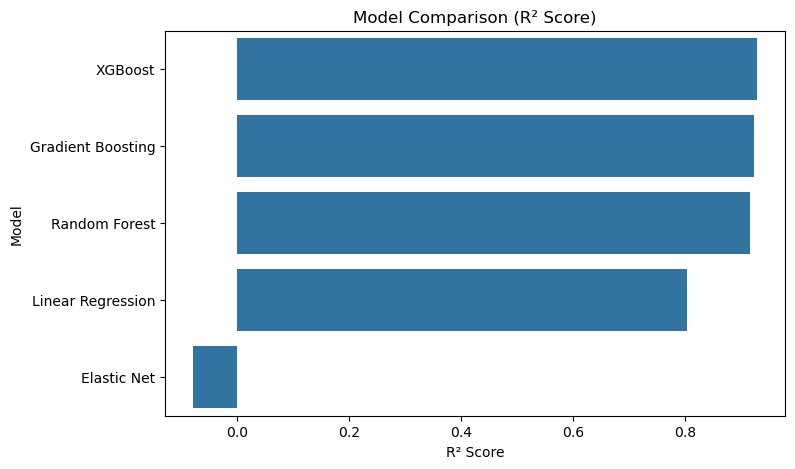

In [69]:
plt.figure(figsize=(8,5))
sns.barplot( data=results_df, x="R² Score", y="Model" )

plt.title("Model Comparison (R² Score)")
plt.show()

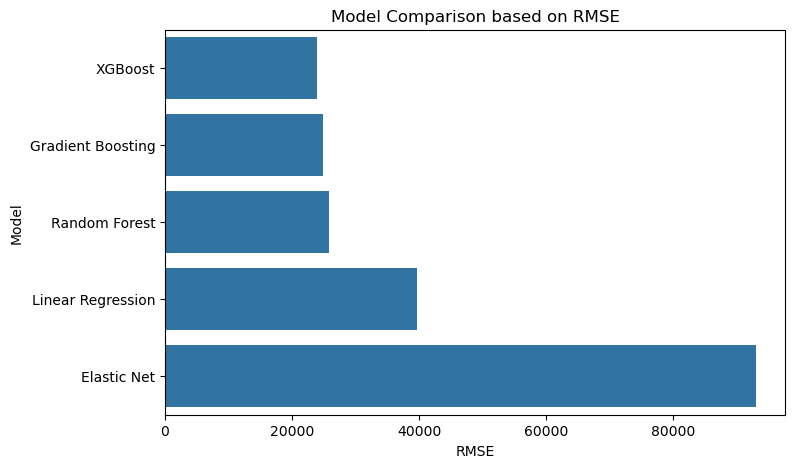

In [70]:
plt.figure(figsize=(8,5))

sns.barplot( data=results_df, x="RMSE", y="Model" )

plt.title("Model Comparison based on RMSE")

plt.xlabel("RMSE")

plt.ylabel("Model")

plt.show()

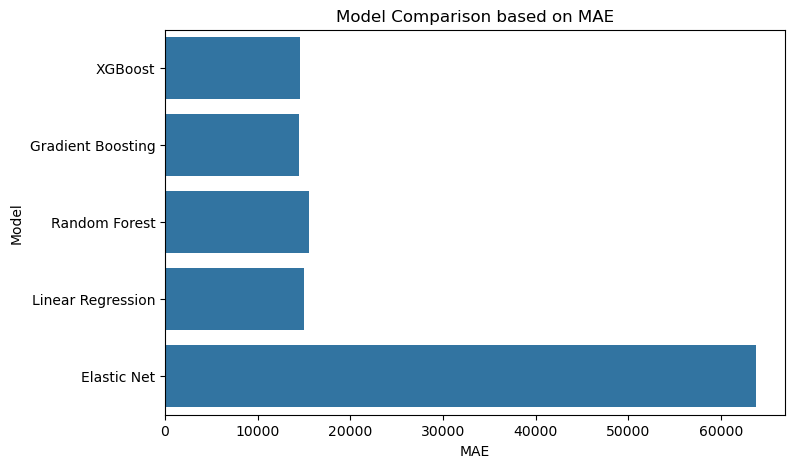

In [71]:
plt.figure(figsize=(8,5))

sns.barplot( data=results_df, x="MAE", y="Model")

plt.title("Model Comparison based on MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

In [72]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: XGBoost


### HyperParameter Tuning

In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [74]:
rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False]
}

In [75]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
print("\nBest CV Score:", rf_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__bootstrap': False}

Best CV Score: 0.8795065730341196


In [76]:
gb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0]
}

In [77]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_random = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

gb_random.fit(X_train, y_train)

print("Best Parameters:", gb_random.best_params_)
print("\nBest CV Score:", gb_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 4, 'model__learning_rate': 0.05}

Best CV Score: 0.903106123904277


In [78]:
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]

}

In [79]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_random = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_random.fit(X_train, y_train)

print("Best Parameters:", xgb_random.best_params_)
print("\nBest CV Score:", xgb_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best CV Score: 0.9038832666807025


In [80]:
def evaluate_model(model, X_test, y_test):

    # Predictions on log scale
    y_pred_log = model.predict(X_test)

    # Convert back to original scale
    y_original = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_original, y_pred)

    rmse = np.sqrt(mean_squared_error(y_original, y_pred))

    r2 = r2_score(y_original, y_pred)


    return {
        "MAE": round(mae,2),
        "RMSE": round(rmse,2),
        "R² Score": round(r2,4),
    }

In [81]:
tuned_results = pd.DataFrame({

    "Random Forest": evaluate_model(
        rf_random.best_estimator_,
        X_test,
        y_test
    ),

    "Gradient Boosting": evaluate_model(
        gb_random.best_estimator_,
        X_test,
        y_test
    ),

    "XGBoost": evaluate_model(
        xgb_random.best_estimator_,
        X_test,
        y_test
    )

}).T 

tuned_results = tuned_results.sort_values(
    by="R² Score",
    ascending=False
)

tuned_results

,MAE,RMSE,R² Score
XGBoost,13477.84,22798.54,0.9352
Gradient Boosting,14314.03,25333.25,0.9200
Random Forest,14984.35,25896.65,0.9164


### Final Model Evaluation

In [82]:
best_model = xgb_random.best_estimator_

y_pred_log = best_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_original = np.expm1(y_test)

After comparing the performance of all trained regression models, **XGBoost** was selected as the final model.

### Reasons for Selection

- Achieved the **highest R² Score (0.9352)**, explaining approximately **93.5%** of the variance in house prices.
- Produced the **lowest MAE (13,477.84)**, indicating the smallest average prediction error.
- Achieved the **lowest RMSE (22,798.54)**, showing better handling of large prediction errors than the other models.

These results demonstrate that XGBoost provides the most accurate and reliable predictions among the evaluated models. Therefore, it was chosen as the final model for deployment.

### Feature Importance

In [83]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

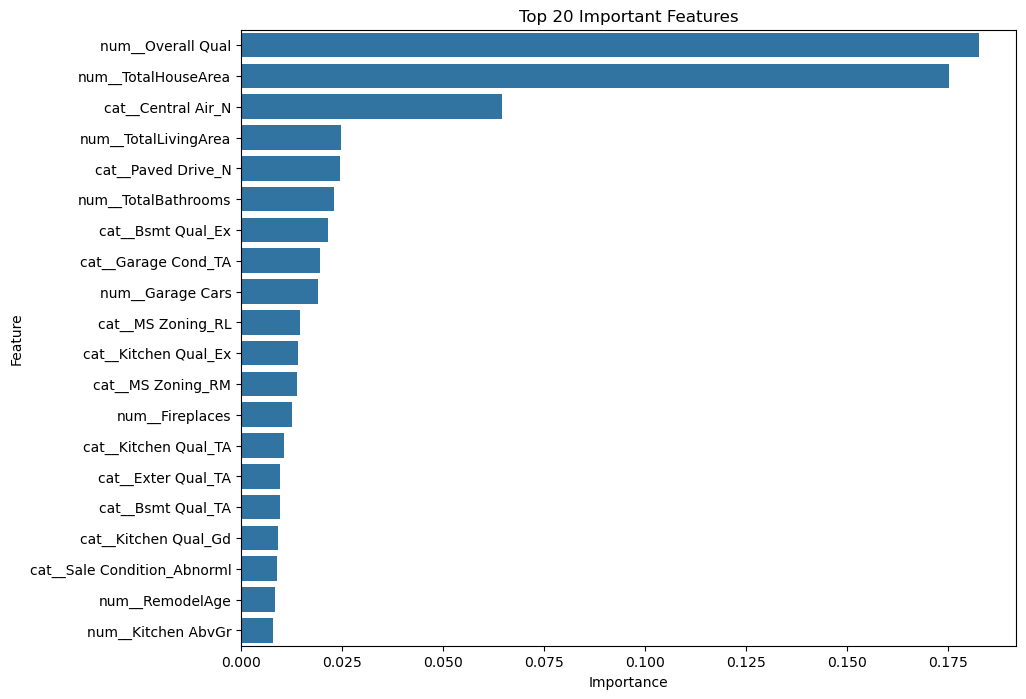

In [84]:
plt.figure(figsize=(10,8))

sns.barplot( data=importance_df.head(20), x="Importance", y="Feature")

plt.title("Top 20 Important Features")

plt.show()

### Prediction Analysis

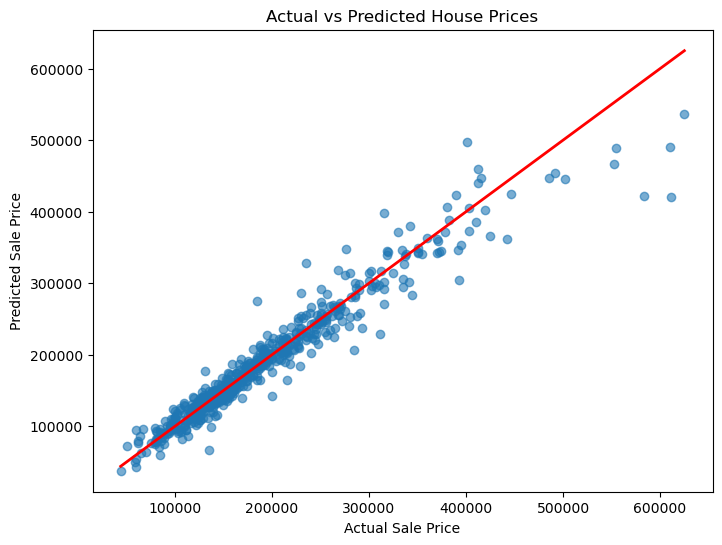

In [85]:
plt.figure(figsize=(8,6))

plt.scatter(y_original, y_pred, alpha=0.6)

plt.plot(
    [y_original.min(), y_original.max()],
    [y_original.min(), y_original.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

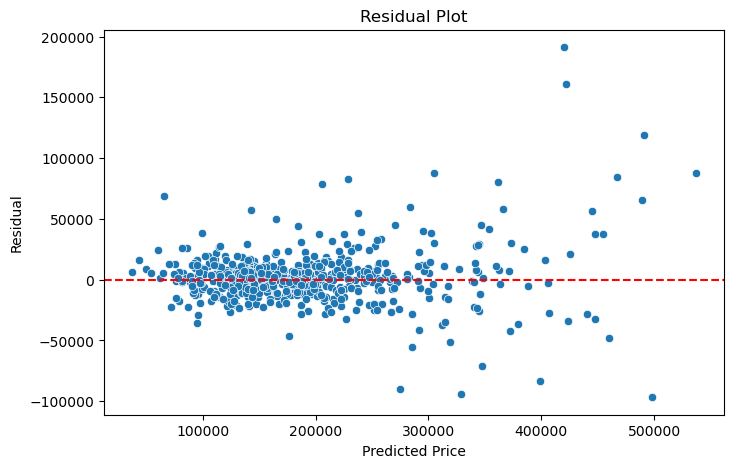

In [86]:
residuals = y_original - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

### Save Final Model

In [87]:
import joblib

joblib.dump(
    xgb_random.best_estimator_,
    "house_price_prediction_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


### Test the Saved Model 

In [88]:
loaded_model = joblib.load(
    "house_price_prediction_pipeline.pkl"
)

In [89]:
# Randomly select 5 houses from the test set
sample = X_test.sample(5)

actual_prices = np.expm1(y_test.loc[sample.index])

predicted_prices = np.expm1(loaded_model.predict(sample))

comparison = pd.DataFrame({
    "Actual Price": actual_prices.values,
    "Predicted Price": predicted_prices,
})

comparison["Absolute Error"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
).abs()

comparison["Percentage Error (%)"] = (
    comparison["Absolute Error"] / comparison["Actual Price"]
) * 100

comparison

,Actual Price,Predicted Price,Absolute Error,Percentage Error (%)
0,214000.0,222855.718750,8855.718750,4.138186
1,250000.0,291180.812500,41180.812500,16.472325
2,159000.0,148394.843750,10605.156250,6.669910
3,129900.0,121858.585938,8041.414063,6.190465
4,235876.0,225054.296875,10821.703125,4.587878


# Conclusion

This project developed an end-to-end machine learning solution for predicting residential house prices using the Ames Housing dataset. The workflow followed a structured machine learning pipeline, including data exploration, data cleaning, exploratory data analysis (EDA), feature engineering, target transformation, preprocessing, model training, hyperparameter tuning, and model evaluation.

A preprocessing pipeline was implemented using Scikit-learn to automate missing value imputation, feature scaling, and one-hot encoding. This ensured consistent preprocessing during both training and inference while preventing data leakage.

Multiple regression models were trained and compared, including Linear Regression, Elastic Net, Random Forest, Gradient Boosting, and XGBoost. Hyperparameter tuning was performed on the top-performing tree-based models using RandomizedSearchCV to improve predictive performance.

Among all evaluated models, **XGBoost** achieved the best overall performance with:

* **MAE:** 13,477.84
* **RMSE:** 22,798.54
* **R² Score:** 0.9352

These results indicate that the final model explains approximately **93.5% of the variation in house prices** while maintaining a low prediction error, making it the most accurate and reliable model for this dataset.

The complete preprocessing pipeline and trained XGBoost model were saved as a single serialized object using `joblib`, enabling seamless deployment without requiring separate preprocessing steps. This approach improves reproducibility, simplifies inference, and supports real-world deployment.

Overall, this project demonstrates the complete machine learning lifecycle—from data preprocessing and feature engineering to model optimization and deployment—and showcases practical skills in regression modeling, pipeline construction, model evaluation, and production-ready machine learning workflows.
